<a href="https://colab.research.google.com/github/Akithma-Thewanjee/Akithma-Thewanjee/blob/main/01_learning_and_tokens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 · Token prediction and a minimal learning bridge

**Question:** How does a language model produce a next-token distribution?

The core path is sections C and D: a tiny word-bigram next-token predictor, temperature, and generation. Section A is an optional one-parameter learning analogy; section B is an optional warning about fitting examples. Neither models LLM training.

Run the setup cell, then run each section you choose from top to bottom with **Shift+Enter**. Before changing an experiment, predict its result. After editing, rerun that cell and the cells that depend on it. **Kernel → Restart Kernel and Run All Cells** checks that you have not relied on hidden state.

Exercises marked **YOUR TURN** deliberately use `None` until you answer. Their checks explain what is missing without stopping a first Run All. A completed exercise must print its PASS message. All examples in this notebook are fictional.

In [8]:
import math
import random
import json
from collections import Counter, defaultdict
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.prop_cycle": plt.cycler(color=["#236d4e", "#e0784c", "#708eaa"]),
    "axes.titlesize": 15, "axes.labelsize": 11
})
print("Ready. No network or model download is needed.")

Ready. No network or model download is needed.


## Optional A · One parameter changes after an error

This 1D toy model predicts `cost = weight × pages`. It only grounds the idea that an error signal can change a parameter; it is not a neural network or a miniature LLM. A target is the observed value the model is trying to predict. Each example follows a fictional price of 3 units per page. Mean squared error (MSE) averages the squared differences between predictions and targets.

**Predict:** should a starting weight of 0.5 rise or fall? The gradient gives the local direction of increasing error. Subtracting a small multiple of it moves the weight toward lower error.

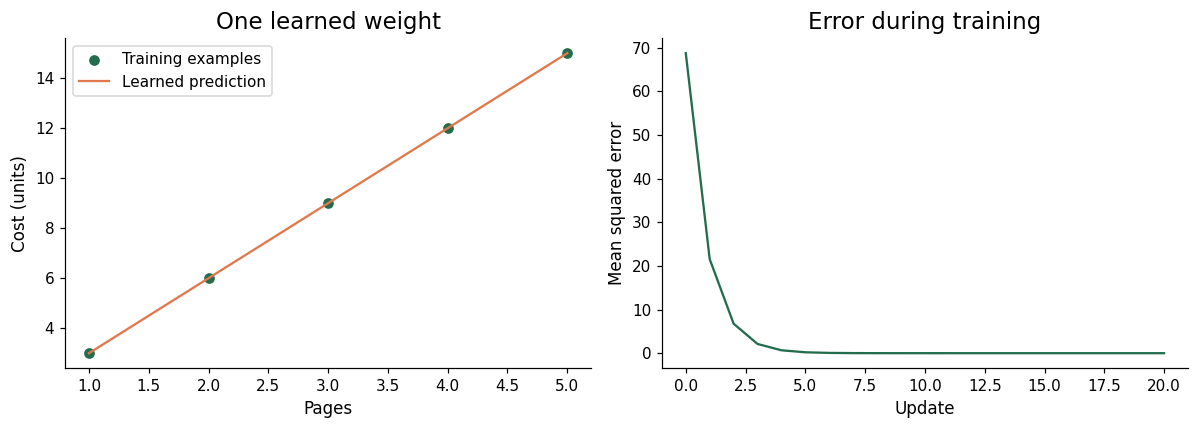

weight=3.0000; final MSE=0.000000


In [9]:
xs = [1, 2, 3, 4, 5]
ys = [3 * x for x in xs]

def mse(weight, inputs=xs, targets=ys):
    return sum((weight*x - y)**2 for x, y in zip(inputs, targets)) / len(inputs)

def train(rate=0.02, steps=20):
    weight = 0.5
    trace = [(0, weight, mse(weight))]
    for step in range(1, steps + 1):
        # For this model, d(MSE)/d(weight) = (2/n) * sum(x * (prediction - target)).
        gradient = 2 * sum(x * (weight*x-y) for x, y in zip(xs, ys)) / len(xs)
        weight -= rate * gradient
        trace.append((step, weight, mse(weight)))
    return weight, trace

weight, trace = train()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(xs, ys, label="Training examples")
axes[0].plot(xs, [weight*x for x in xs], label="Learned prediction", color="#e0784c")
axes[0].set(xlabel="Pages", ylabel="Cost (units)", title="One learned weight")
axes[0].legend()
axes[1].plot([t[0] for t in trace], [t[2] for t in trace])
axes[1].set(xlabel="Update", ylabel="Mean squared error", title="Error during training")
plt.tight_layout()
plt.show()
print(f"weight={weight:.4f}; final MSE={mse(weight):.6f}")
assert mse(weight) < mse(0.5)

### Optional YOUR TURN · The update rule

Complete `new_weight`. Test that a positive gradient moves the weight down, and a negative gradient moves it up. This is one numerical update, not a complete training system.

In [10]:
def update(weight, gradient, learning_rate):
    new_weight = None  # YOUR TURN
    return new_weight

if update(2.0, 4.0, 0.1) is None:
    print("YOUR TURN A: implement the update, then rerun.")
else:
    assert math.isclose(update(2.0, 4.0, 0.1), 1.6)
    assert math.isclose(update(2.0, -4.0, 0.1), 2.4)
    assert update(2.0, 0.0, 0.1) == 2.0
    print("PASS A: the update follows the gradient direction.")

YOUR TURN A: implement the update, then rerun.


## Optional B · Fitting examples is not enough

This is a general ML warning, not an LLM training recipe. Compare a modest learning rate with one that overshoots. Then test inputs withheld from training and change the pricing rule to include a fixed fee.

**Explain:** Why can a model fit its training data yet fail when the real world changes?

In [11]:
for rate in [0.02, 0.1]:
    w, history = train(rate=rate, steps=12)
    print(f"rate={rate}: final MSE={history[-1][2]:.3f}")

held_out = [6, 7]
same_rule_error = mse(weight, held_out, [3*x for x in held_out])
changed_rule_error = mse(weight, held_out, [10+3*x for x in held_out])
print("Held-out, same pricing rule:", round(same_rule_error, 6))
print("Held-out, new fixed fee:", round(changed_rule_error, 3))
assert changed_rule_error > same_rule_error
# Change the model to bias + weight*x as an extension.

rate=0.02: final MSE=0.000
rate=0.1: final MSE=5465.408
Held-out, same pricing rule: 0.0
Held-out, new fixed fee: 100.003


## Core C · A tiny word-bigram next-token predictor

Our tokenizer splits on whitespace. The predictor estimates `P(next word | previous word)` from observed word-pair counts. It is a language-model baseline because it produces next-token probabilities, but it cannot use long context and is not a transformer or LLM.

The corpus repeats some phrases more often. Find the counts after `base` before running the next cell.

Counts after base: {'case': 6, 'condition': 2, 'value': 1}


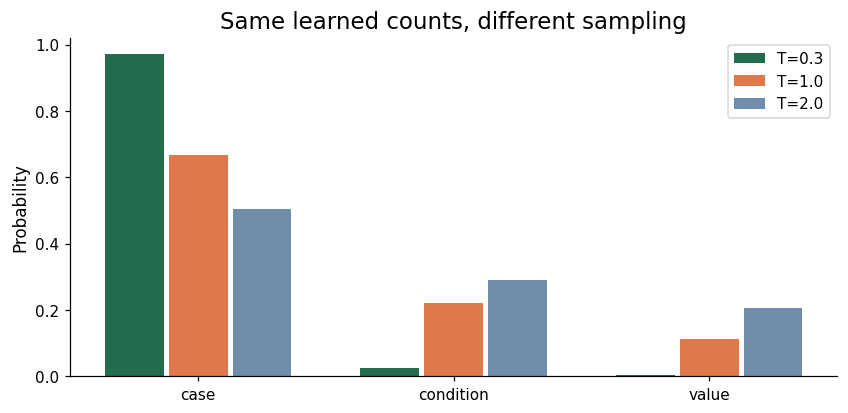

In [12]:
sentences = (
    ["a recursive function needs a base case"] * 6
    + ["a recursive function needs a base condition"] * 2
    + ["the base value is zero"]
    + ["a loop needs an exit condition"]
)
counts = defaultdict(Counter)
for sentence in sentences:
    words = ["<BOS>"] + sentence.split() + ["<EOS>"]
    for previous, following in zip(words, words[1:]):
        counts[previous][following] += 1

def distribution(previous, temperature=1.0):
    if temperature <= 0:
        raise ValueError("Use a positive temperature in this toy sampler.")
    choices = counts.get(previous)
    if not choices:
        return {"<EOS>": 1.0}  # Explicit unknown-context fallback
    logits = {word: math.log(count) / temperature for word, count in choices.items()}
    maximum = max(logits.values())
    weights = {word: math.exp(value-maximum) for word, value in logits.items()}
    total = sum(weights.values())
    return {word: value/total for word, value in weights.items()}

print("Counts after base:", dict(counts["base"]))
fig, ax = plt.subplots()
labels = sorted(counts["base"])
for i, temperature in enumerate([0.3, 1.0, 2.0]):
    probs = distribution("base", temperature)
    ax.bar([j + i*0.25 for j in range(len(labels))],
           [probs[label] for label in labels], width=0.23, label=f"T={temperature}")
ax.set_xticks([j+0.25 for j in range(len(labels))], labels)
ax.set(ylabel="Probability", title="Same learned counts, different sampling")
ax.legend()
plt.show()

### YOUR TURN C · Temperature changes the distribution

Choose `sharper_temperature` as either `0.3` or `2.0`. Which gives the most common continuation, `case`, more probability? Explain why this does not add facts to the model.

In [13]:
sharper_temperature = None  # YOUR TURN: 0.3 or 2.0
if sharper_temperature is None:
    print("YOUR TURN C: make a prediction, then set a temperature.")
else:
    assert sharper_temperature in (0.3, 2.0)
    assert distribution("base", sharper_temperature)["case"] > distribution("base", 1.0)["case"]
    print("PASS C: the distribution is sharper. The counts did not change.")

YOUR TURN C: make a prediction, then set a temperature.


## Core D · Generation repeats next-token prediction

A selected token becomes part of the generated sequence. This bigram conditions only on the immediately preceding word. A transformer conditions on a bounded sequence of preceding tokens through contextual representations.

**Change:** edit `seed`, `temperature`, or `prefix`. Unknown words end generation under our explicit fallback. A seed makes this small experiment reproducible, not factually reliable.

In [14]:
def generate(prefix="a recursive function", temperature=1.0, seed=7, max_new_tokens=12):
    rng = random.Random(seed)
    words = prefix.split()
    for _ in range(max_new_tokens):
        probs = distribution(words[-1] if words else "<BOS>", temperature)
        token = rng.choices(list(probs), weights=list(probs.values()), k=1)[0]
        if token == "<EOS>":
            break
        words.append(token)
    return " ".join(words)

before = json.dumps({k: dict(v) for k, v in counts.items()}, sort_keys=True)
for seed in [1, 2, 3]:
    print(generate(temperature=2.0, seed=seed))
after = json.dumps({k: dict(v) for k, v in counts.items()}, sort_keys=True)
assert before == after
print("Inference changed the generated sequence, not the learned counts.")

a recursive function needs an exit condition
a recursive function needs an exit condition
a recursive function needs a recursive function needs a recursive function needs a loop needs
Inference changed the generated sequence, not the learned counts.


## Explain what you observed

1. What changed during training? What changed during generation?
2. Why does our bigram model forget everything except the last word?
3. Does generating more tokens create new evidence? Explain why or why not.
4. What can an error score on an old data pattern fail to tell you?

A transformer turns token IDs into contextual vectors, produces scores for possible next tokens, and uses a decoding rule to select one. This notebook isolates two smaller ideas: one parameter update and token generation.

**Reading:** [Transformer architecture](https://arxiv.org/abs/1706.03762).